In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy
import pickle
import math
import solvers
import sde
import dnnlib
from solvers import edm_sampler

torch.manual_seed(0)

In [2]:
with dnnlib.util.open_url("model/edm2-img64-xl-0671088-0.040.pkl") as f:
    data = pickle.load(f)
model = data["ema"].to("cuda")

In [3]:
encoder = data.get('encoder', None)
if encoder is None:
    encoder = dnnlib.util.construct_class_by_name(class_name='training.encoders.StandardRGBEncoder')

In [4]:
x = torch.zeros((16, model.img_channels, model.img_resolution, model.img_resolution)).to("cuda")
t = torch.ones((1,)).to("cuda")
noise = torch.randn_like(x) * 80

In [13]:
labels = torch.eye(model.label_dim, device="cuda")[torch.randint(high=model.label_dim, size=(16,), device="cuda")]

In [14]:
sigma_min = 0.002
sigma_max = 80

sde_ = sde.EDMSDE().to("cuda")
rsde = sde_.get_reverse_sde(model, ode_threshold=0.2).to("cuda")
rsde.ode = False

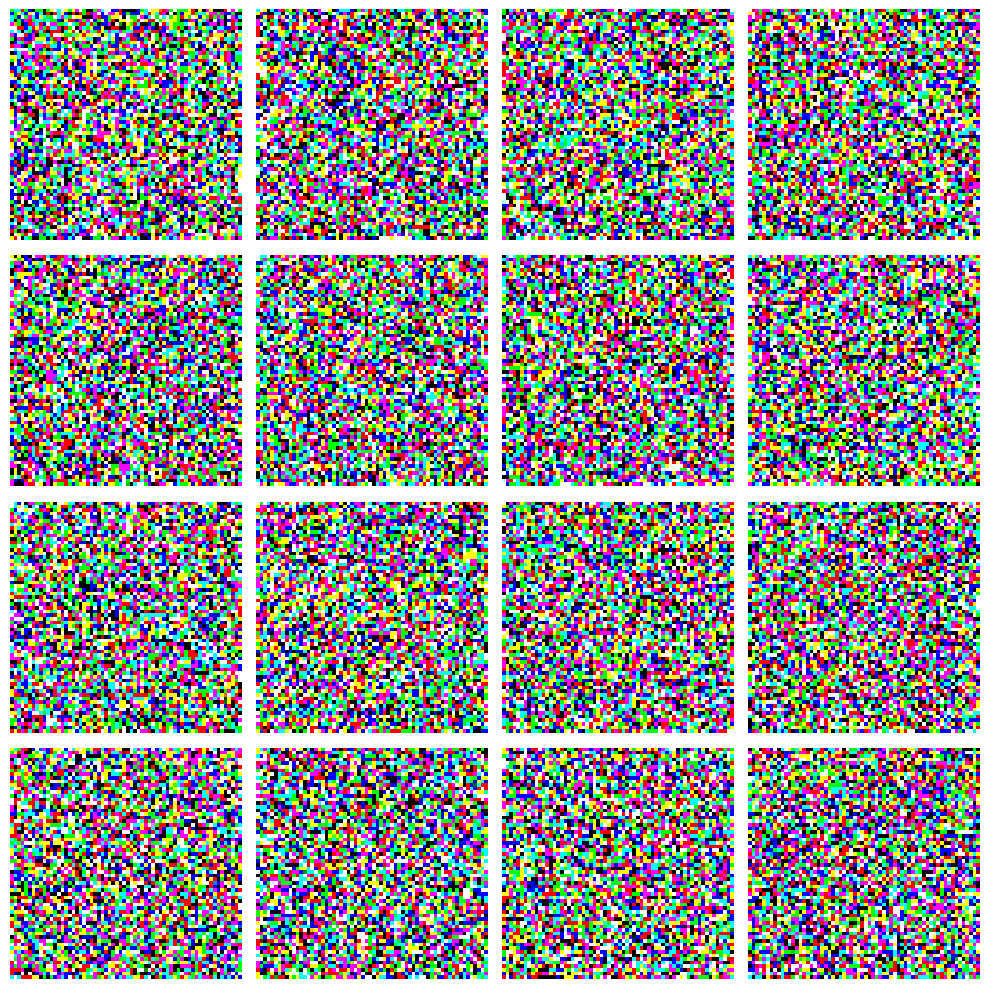

In [15]:
images = encoder.decode(noise).permute(0, 2, 3, 1)

def plot_images(images):
    fig, axes = plt.subplots(4, 4)
    fig.set_size_inches(10, 10)
    
    for i in range(4):
        for j in range(4):
            axes[i][j].imshow(images[i * 4 + j])
            axes[i][j].axis("off")
            
    fig.tight_layout()
    
plot_images(images.cpu())

In [16]:
n_steps = 70
rho = 7
# From EDM2 code
step_indices = torch.arange(n_steps)
sigma_steps = (sigma_max ** (1 / rho) + step_indices / (n_steps - 1) * (sigma_min ** (1 / rho) - sigma_max ** (1 / rho))) ** rho
discretisation = torch.cat([sigma_steps, torch.zeros_like(sigma_steps[:1])])

In [9]:
rsde.reset()

em_solver = solvers.EulerMarayumaSolver(rsde, discretisation).to("cuda")

x_em = em_solver.solve(noise.clone(), labels)

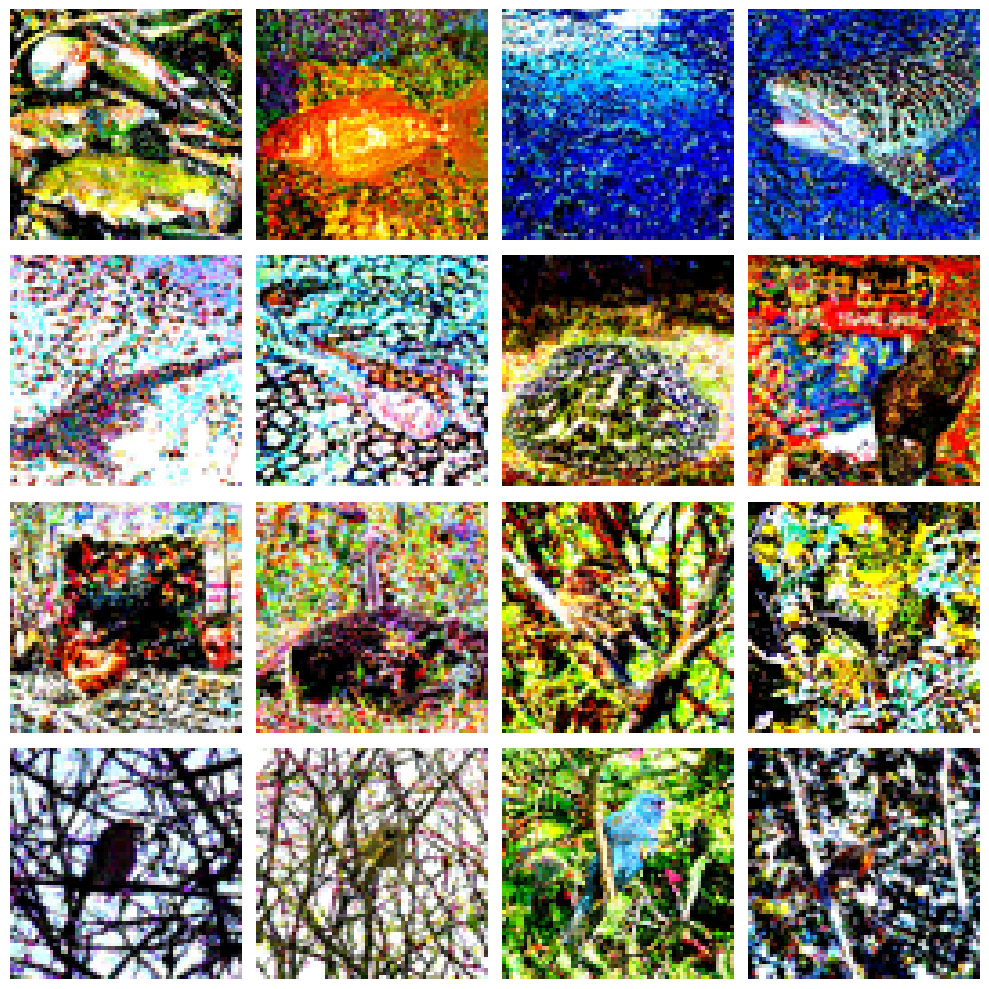

In [10]:
images = encoder.decode(x_em).permute(0, 2, 3, 1)

plot_images(images.cpu())

In [9]:
sigmas = []
sigmas_std = []
def pi_callback(x, t, h, error):    
    print(f"sigma = {torch.mean(t)}", end=" ")
    print(f"h = {torch.mean(h)}", end=" ")
    print(f"error = {torch.mean(error)}")
    sigmas.append(torch.mean(t).cpu())
    sigmas_std.append(torch.std(t).cpu())

In [18]:
sigmas = []
sigmas_std = []

rsde.reset()

pi_solver = solvers.PISolver(
    rsde,
    ki=0.3,
    kp=0.1, 
    tau_a=0.3,
    tau_r=3,
    alpha=0.9,
    h_start=10,
    max_decrease=0.05,
    max_increase=5,
    interval=(80, 0),
    abs_error=False
).to("cuda")

x_pi = pi_solver.solve(noise.clone(), labels, callback=pi_callback)

sigma = 70.0 h = -9.804580688476562 error = 0.33090704679489136
sigma = 60.19541931152344 h = -8.493659973144531 error = 0.4067305028438568
sigma = 51.701759338378906 h = -7.456552505493164 error = 0.41422706842422485
sigma = 44.245208740234375 h = -6.446831703186035 error = 0.43234941363334656
sigma = 37.79837417602539 h = -5.5493011474609375 error = 0.4418365955352783
sigma = 32.24907684326172 h = -4.755230903625488 error = 0.4492824077606201
sigma = 27.49384307861328 h = -4.073127746582031 error = 0.45163610577583313
sigma = 23.42071533203125 h = -3.474882125854492 error = 0.4567628800868988
sigma = 19.945833206176758 h = -2.9640445709228516 error = 0.4582509398460388
sigma = 16.981788635253906 h = -2.5260143280029297 error = 0.4596482515335083
sigma = 14.455774307250977 h = -2.1540465354919434 error = 0.4592966139316559
sigma = 12.301727294921875 h = -1.8355551958084106 error = 0.4600357413291931
sigma = 10.466172218322754 h = -1.563309907913208 error = 0.4608345031738281
sigma = 8

In [19]:
rsde.nfe / 16

72.125

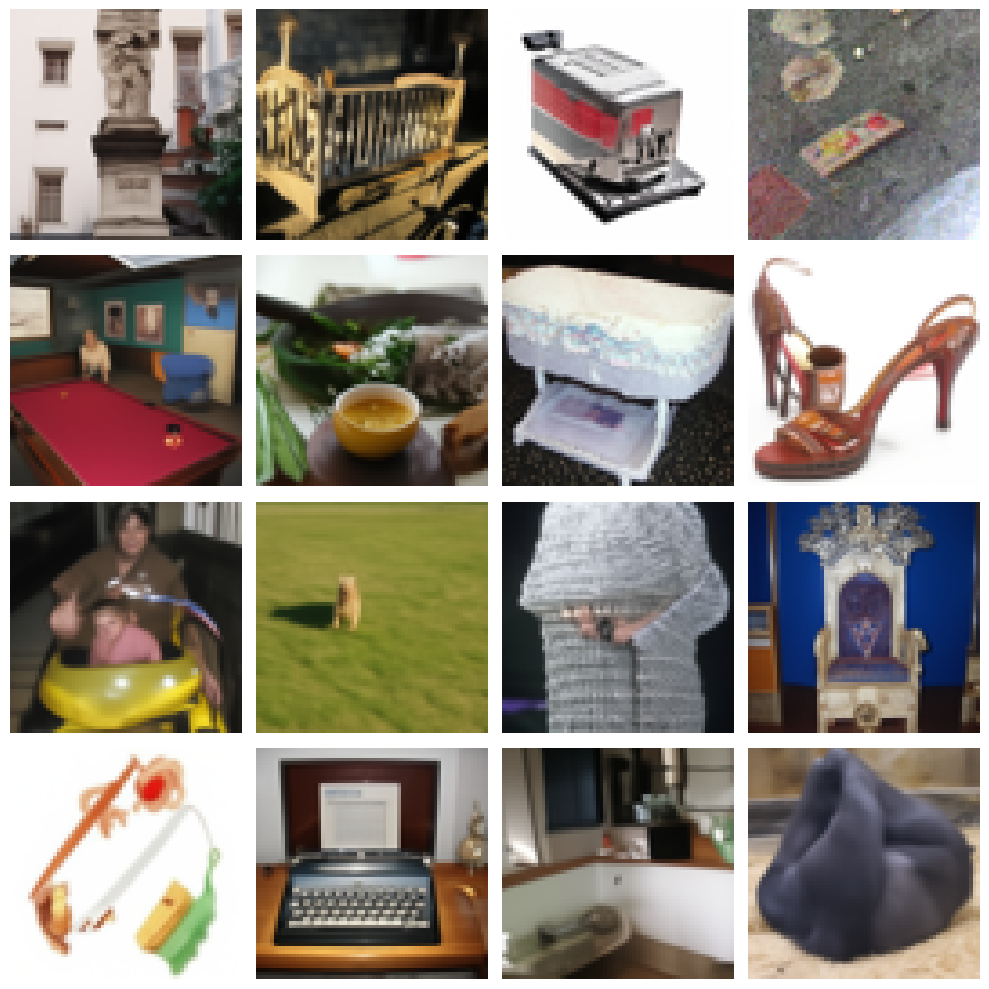

In [20]:
images = encoder.decode(x_pi).permute(0, 2, 3, 1)
plot_images(images.cpu())

Text(0, 0.5, 'sigma')

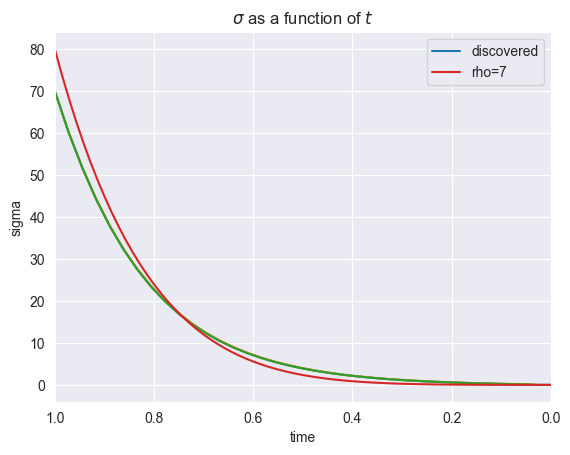

In [21]:
plt.title(r"$\sigma$ as a function of $t$")
plt.plot(torch.linspace(1, 0, len(sigmas)), sigmas, label="discovered")
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) + torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(sigmas)), torch.tensor(sigmas) - torch.tensor(sigmas_std))
plt.plot(torch.linspace(1, 0, len(discretisation)), discretisation.cpu(), label="rho=7")
plt.legend()
plt.xlim(1, 0)
plt.xlabel("time")
plt.ylabel("sigma")

In [22]:
x_edm = edm_sampler(model, noise.clone() / 80, labels, num_steps=n_steps // 2)

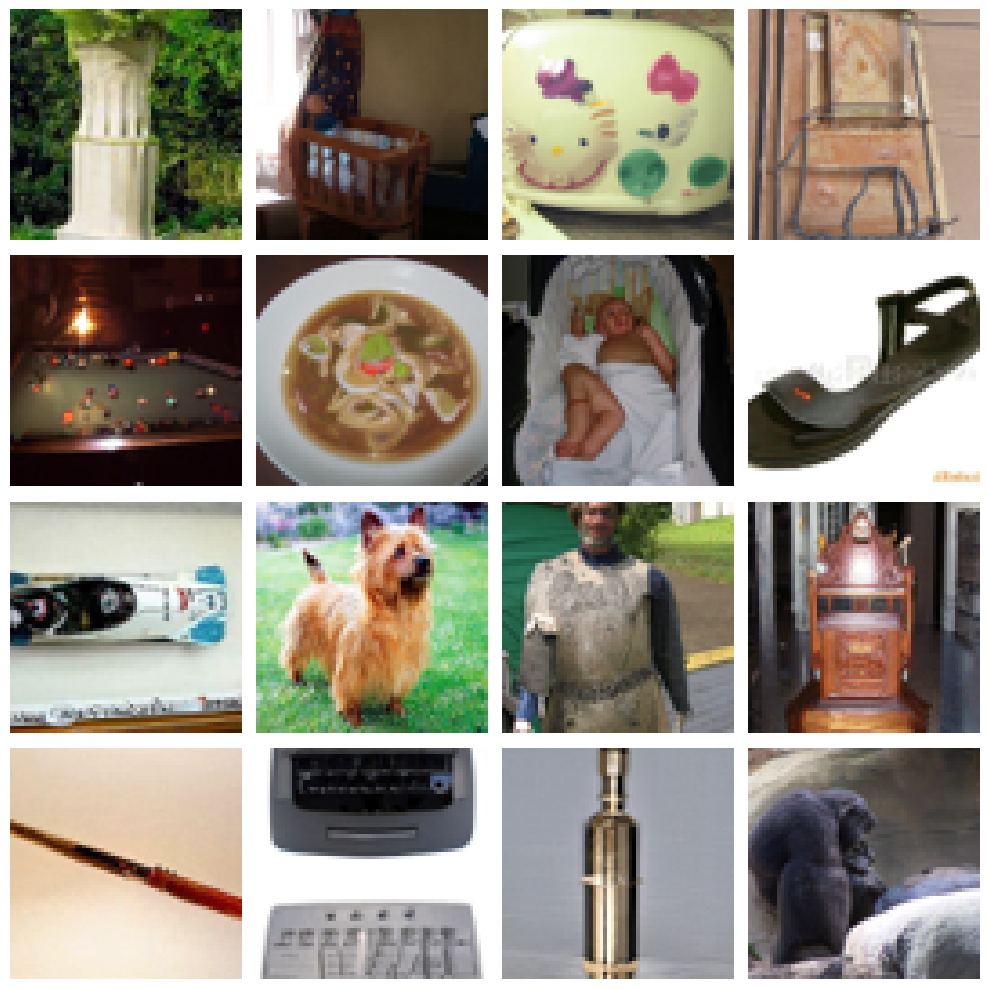

In [23]:
images = encoder.decode(x_edm).permute(0, 2, 3, 1)
plot_images(images.cpu())

In [6]:
df_h = pd.read_csv("image_testing/pi/test/data/_h.csv")
df_t = pd.read_csv("image_testing/pi/test/data/_t.csv")

In [7]:
df_t

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,140,141,142,143,144,145,146,147,148,149
0,0,77.0,72.74491,67.768660,62.054424,55.861683,49.485405,43.182796,37.184338,31.676067,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,77.0,72.74490,67.745865,62.018020,55.833840,49.474262,43.169678,37.188450,31.676083,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,77.0,72.74393,67.750435,62.020240,55.829140,49.448060,43.152298,37.166004,31.614014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,77.0,72.74429,67.738700,62.009632,55.833923,49.469486,43.185944,37.189423,31.675102,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,77.0,72.74434,67.747550,62.042610,55.854210,49.475790,43.170160,37.168568,31.633130,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,35,77.0,72.74552,67.737114,61.990180,55.817383,49.451588,43.128075,37.104640,31.582340,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
996,36,77.0,72.74550,67.770230,62.064827,55.868958,49.471626,43.213493,37.205276,31.691120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
997,37,77.0,72.74565,67.752625,62.052254,55.878387,49.528960,43.253773,37.268887,31.753305,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
998,38,77.0,72.74628,67.752235,62.031240,55.835210,49.443752,43.102055,37.104603,31.583014,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
